In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Load functional data
from eyewire2_functional_analysis import data_loader

data_folder = "../../../data/preprocessed-data"

df_rois, df_fields, df_outline = data_loader.load_all_dfs(data_folder)
print(df_rois.shape)
print(list(df_rois.columns))
df_rois.head()
print(df_fields.shape)
print(list(df_fields.columns))
df_fields.head()

(379, 86)
['experimenter', 'date', 'exp_num', 'raw_id', 'field', 'region', 'cond1', 'ch0_name', 'ch1_name', 'roi_id', 'chirp', 'cond2', 'preprocess_id', 'bar', 'mc', 'chirp_stim_name', 'bar_stim_name', 'classifier_id', 'genline', 'animgender', 'eye', 'setupid', 'prepwmorient', 'nxpix', 'nypix', 'pixel_size_um', 'field_ventral_dorsal_pos_um', 'field_temporal_nasal_pos_um', 'ch0_average', 'ch1_average', 'roi_size_um2', 'roi_dia_um', 'ventral_dorsal_pos_um', 'temporal_nasal_pos_um', 'chirp_trace', 'chirp_trace_t0', 'chirp_trace_dt', 'chirp_pp_trace', 'chirp_pp_trace_t0', 'chirp_pp_trace_dt', 'chirp_qidx', 'chirp_pres_qidx', 'chirp_average_norm', 'chirp_average_dt', 'chirp_snippets', 'chirp_snippets_t0', 'chirp_snippets_dt', 'chirp_triggertimes_snippets', 'bar_trace', 'bar_trace_t0', 'bar_trace_dt', 'bar_pp_trace', 'bar_pp_trace_t0', 'bar_pp_trace_dt', 'bar_ds_index', 'bar_ds_pvalue', 'bar_pref_dir', 'bar_os_index', 'bar_os_pvalue', 'bar_pref_or', 'bar_qidx', 'bar_dir_component', 'bar_time

,experimenter,date,exp_num,raw_id,field,region,cond1,ch0_name,ch1_name,genline,...,setupid,prepwmorient,nxpix,nypix,pixel_size_um,field_ventral_dorsal_pos_um,field_temporal_nasal_pos_um,ch0_average,ch1_average,roi_mask
0,Franke,2018-10-11,2,1,GCL0,RR,control,wDataCh0,wDataCh1,Bl6,...,3,180,64,64,1.46998,-361.4,-841.8,"[[11019.5, 11015.0, 11022.0, 11064.0, 11099.0,...","[[10969.0, 10970.0, 10965.0, 10964.0, 10963.0,...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
1,Franke,2018-10-11,2,1,GCL1,RR,control,wDataCh0,wDataCh1,Bl6,...,3,180,64,64,1.46998,-317.2,-761.4,"[[12043.0, 11088.0, 11062.0, 11028.0, 11037.0,...","[[10983.5, 10968.0, 10971.0, 10955.0, 10949.0,...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
2,Franke,2018-10-11,2,1,GCL2,RR,control,wDataCh0,wDataCh1,Bl6,...,3,180,64,64,1.46998,-317.2,-985.4,"[[11937.0, 11062.0, 11219.0, 11164.0, 11034.0,...","[[10976.0, 10955.0, 10959.0, 10954.0, 10945.0,...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
3,Franke,2018-10-11,2,1,GCL3,RR,control,wDataCh0,wDataCh1,Bl6,...,3,180,64,64,1.46998,-558.0,-935.2,"[[11037.0, 11081.0, 11081.0, 11079.0, 11052.0,...","[[10961.0, 16017.0, 16016.0, 15772.0, 14516.0,...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
4,Franke,2018-10-11,2,1,GCL4,RR,control,wDataCh0,wDataCh1,Bl6,...,3,180,64,64,1.46998,-489.6,-622.2,"[[11002.0, 11050.0, 11056.0, 11040.0, 11033.0,...","[[10948.0, 10948.0, 10950.0, 10948.0, 10949.0,...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."


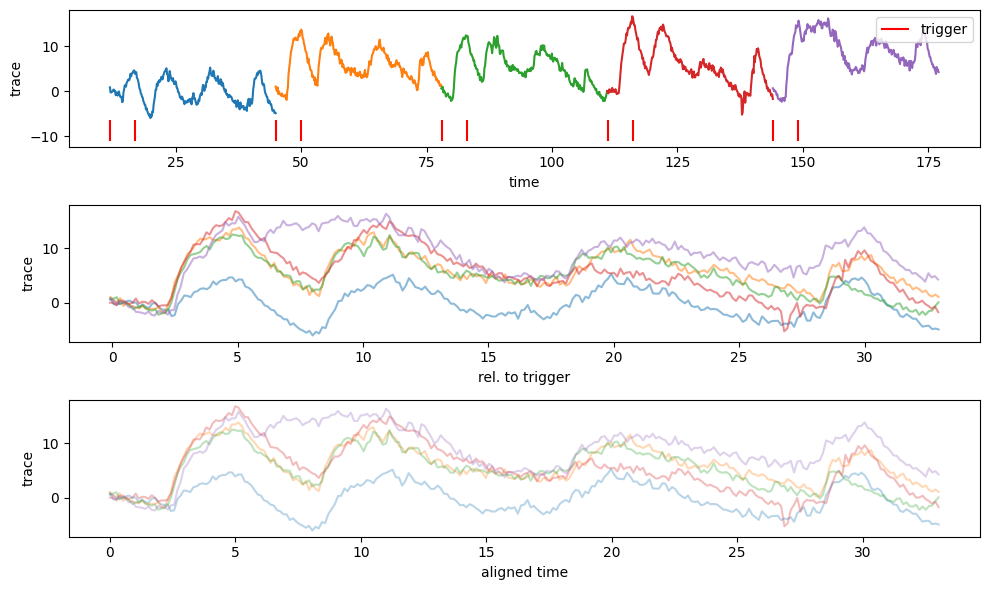

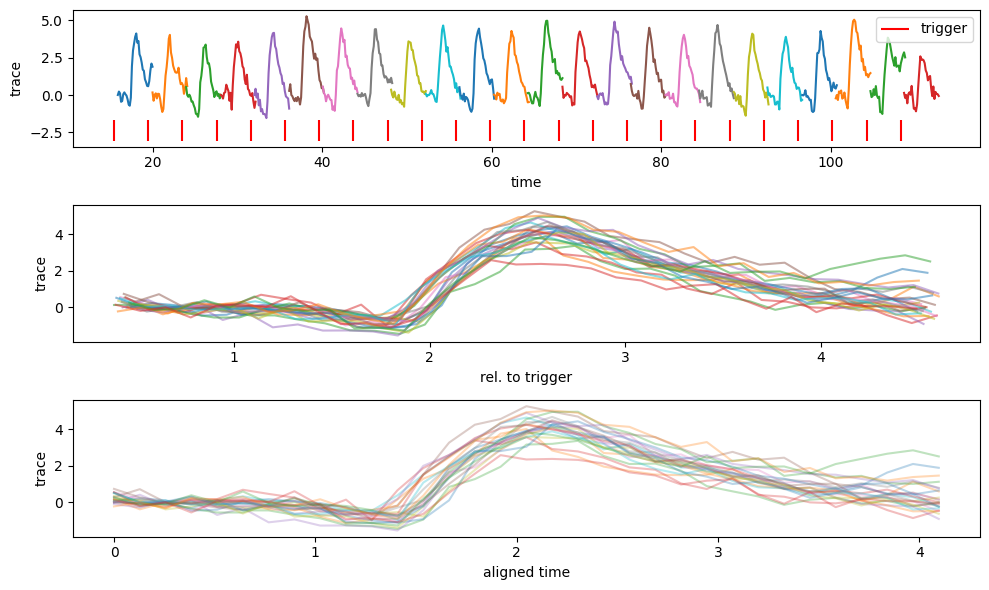

In [3]:
from matplotlib import pyplot as plt
import numpy as np

from eyewire2_functional_analysis import plot_traces

row = df_rois[(df_rois.bar_qidx > 0.6) & (df_rois.chirp_qidx > 0.6)].iloc[0]
for stim in ['chirp', 'bar']:
    snippets_t0 = row[f'{stim}_snippets_t0']
    snippets_dt = row[f'{stim}_snippets_dt']
    snippets = row[f'{stim}_snippets']
    triggertimes_snippets = row[f'{stim}_triggertimes_snippets']

    snippets_times = (np.tile(np.arange(snippets.shape[0]) * snippets_dt, (len(snippets_t0), 1)).T
                      + snippets_t0)

    fig, axs = plt.subplots(3, 1, figsize=(10, 6))

    plot_traces.plot_trace_and_trigger(
        ax=axs[0], time=snippets_times, trace=snippets, triggertimes=triggertimes_snippets)

    axs[1].plot(snippets_times - triggertimes_snippets[0], snippets, alpha=0.5)
    axs[1].set(ylabel='trace', xlabel='rel. to trigger')

    aligned_times = plot_traces.get_aligned_snippets_times(snippets_times=snippets_times)
    plot_traces.plot_traces(
        ax=axs[2], time=aligned_times, traces=snippets.T)
    axs[2].set(ylabel='trace', xlabel='aligned time')

    plt.tight_layout()